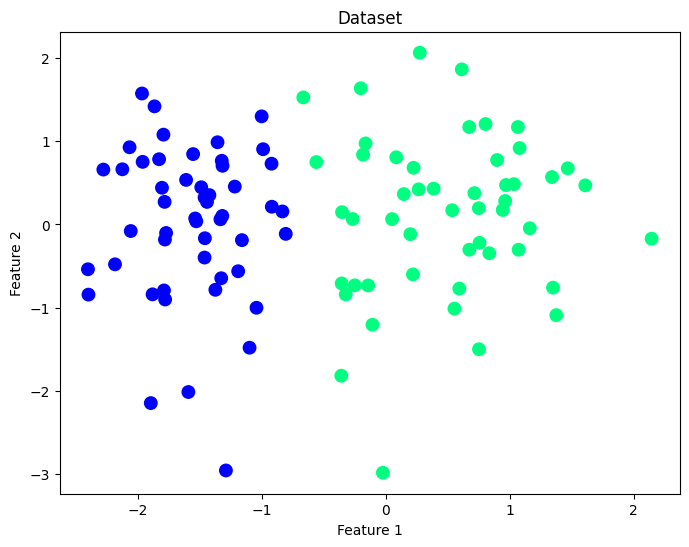

Perceptron weights: [0.9        1.3878435  0.10597147]


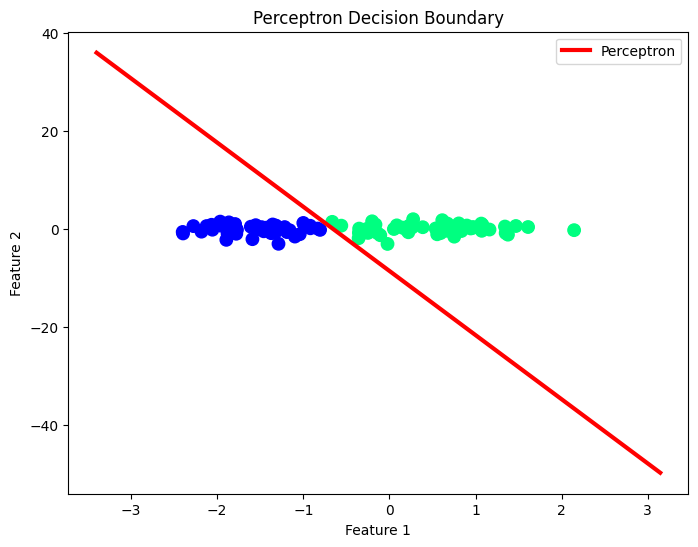

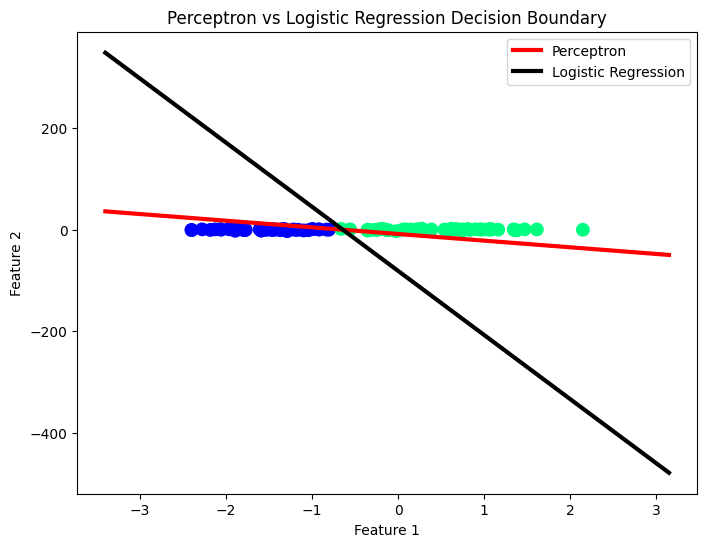

In [1]:
# 1. IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression


# 2. CREATE A SIMPLE BINARY CLASSIFICATION DATASET
X, y = make_classification(
    n_samples=100,        # total 100 points
    n_features=2,         # 2 features (x1, x2) so we can draw them on 2D graph
    n_informative=1,      # only 1 feature is actually useful
    n_redundant=0,        # no redundant (extra) features
    n_classes=2,          # 2 classes: 0 and 1
    n_clusters_per_class=1,
    random_state=41,      # for reproducible results
    hypercube=False,
    class_sep=10          # keep classes well separated
)

# 3. VISUALIZE THE DATA
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=80)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# 4. STEP FUNCTION FOR PERCEPTRON
def step(z):
    return 1 if z > 0 else 0


# 5. PERCEPTRON ALGORITHM (LEARN LINEAR DECISION BOUNDARY)
def perceptron(X, y, lr=0.1, epochs=20):
    """
    X : input features (shape: [n_samples, 2])
    y : labels (0 or 1)
    lr: learning rate
    epochs : how many times to go over all data
    """
    # 5.1 Add bias column of 1s at index 0
    X_bias = np.insert(X, 0, 1, axis=1)   # shape becomes [n_samples, 3]

    # 5.2 Initialize weights (bias, w1, w2) to 1
    weights = np.ones(X_bias.shape[1])

    # 5.3 Training loop
    for epoch in range(epochs):
        for i in range(len(y)):
            # 5.3.1 Prediction
            z = np.dot(X_bias[i], weights)    # linear combination
            y_hat = step(z)                   # apply step function

            # 5.3.2 Update weights
            error = y[i] - y_hat
            weights = weights + lr * error * X_bias[i]

    return weights


# 6. TRAIN PERCEPTRON AND GET WEIGHTS
weights = perceptron(X, y, lr=0.1, epochs=20)
bias = weights[0]
w1 = weights[1]
w2 = weights[2]
print("Perceptron weights:", weights)

# 7. DRAW PERCEPTRON DECISION BOUNDARY
# Equation: w1*x1 + w2*x2 + bias = 0  → x2 = -(w1/w2)*x1 - (bias/w2)
m_perc = -(w1 / w2)           # slope
b_perc = -(bias / w2)         # intercept

x_line = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_line = m_perc * x_line + b_perc

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=80)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Perceptron')
plt.title("Perceptron Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


# 8. TRAIN LOGISTIC REGRESSION
log_reg = LogisticRegression()
log_reg.fit(X, y)

# 9. GET LOGISTIC REGRESSION LINE
# Decision boundary: w1*x1 + w2*x2 + b = 0 → x2 = -(w1/w2)*x1 - (b/w2)
w1_lr = log_reg.coef_[0][0]
w2_lr = log_reg.coef_[0][1]
b_lr = log_reg.intercept_[0]

m_lr = -(w1_lr / w2_lr)
b_lr = -(b_lr / w2_lr)

y_line_lr = m_lr * x_line + b_lr

# 10. PLOT BOTH LINES TOGETHER
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=80)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Perceptron')
plt.plot(x_line, y_line_lr, color='black', linewidth=3, label='Logistic Regression')
plt.title("Perceptron vs Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
